In [39]:
import os
import json
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [40]:
from pathlib import Path

DATASET_DIR = Path("/kaggle/input/datasets/youssef00ebrahim/ocr-ds")

image_files = list(DATASET_DIR.glob("*.png")) + \
              list(DATASET_DIR.glob("*.jpg")) + \
              list(DATASET_DIR.glob("*.jpeg"))

text_files = list(DATASET_DIR.glob("*.txt"))

print(f"Dataset Directory : {DATASET_DIR}")
print(f"Image Files       : {len(image_files)}")
print(f"Text Files        : {len(text_files)}")

Dataset Directory : /kaggle/input/datasets/youssef00ebrahim/ocr-ds
Image Files       : 19992
Text Files        : 19992


In [41]:
from pathlib import Path

image_paths = []
labels = []

SUPPORTED_EXTENSIONS = (".jpg", ".jpeg", ".png")

for image_path in sorted(DATASET_DIR.iterdir()):

    if image_path.suffix.lower() not in SUPPORTED_EXTENSIONS:
        continue

    txt_path = image_path.with_suffix(".txt")

    if not txt_path.exists():
        print(f"Missing label: {txt_path.name}")
        continue

    text = txt_path.read_text(encoding="utf-8").strip()

    image_paths.append(str(image_path))
    labels.append(text)

print(f"Total Samples: {len(image_paths)}")

Total Samples: 19992


In [42]:
for i in range(5):
    print(image_paths[i])
    print(labels[i])
    print("-"*40)

/kaggle/input/datasets/youssef00ebrahim/ocr-ds/0.jpg
1551 شارع دالكروس متفرع من بورنيموث في ٧٩٤ حمامة العموش
----------------------------------------
/kaggle/input/datasets/youssef00ebrahim/ocr-ds/1.jpg
1641 شارع أم الرخم متفرع من زحوم في ١٢٥٨ أردناستانغ
----------------------------------------
/kaggle/input/datasets/youssef00ebrahim/ocr-ds/10.jpg
1488 شارع نورث كويتس متفرع من غريت هاتون في ١٥٨٩ الحكور
----------------------------------------
/kaggle/input/datasets/youssef00ebrahim/ocr-ds/100.jpg
961 شارع الريحانية متفرع من ويست بريتون في ٨٠٣ نيو كيلباتريك
----------------------------------------
/kaggle/input/datasets/youssef00ebrahim/ocr-ds/1000.jpg
820 شارع الدليلة متفرع من دير الصمادية الشمالي في ٦٢٨ المأمونية
----------------------------------------


In [43]:
assert len(image_paths) == len(labels)

print("Dataset OK")
print("Samples:", len(labels))

Dataset OK
Samples: 19992


In [44]:
all_text = "".join(labels)

vocab_chars = sorted(set(all_text))

print(vocab_chars)
print("Vocabulary Size:", len(vocab_chars))

[' ', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'a', 'b', 'c', 'i', 'r', 'ú', 'ء', 'أ', 'ؤ', 'إ', 'ئ', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ى', 'ي', 'ّ', '٠', '١', '٢', '٣', '٤', '٥', '٦', '٧', '٨', '٩']
Vocabulary Size: 64


In [45]:
from tensorflow.keras.layers import StringLookup

char_to_num = StringLookup(
    vocabulary=vocab_chars,
    mask_token=None
)

num_to_char = StringLookup(
    vocabulary=char_to_num.get_vocabulary(),
    invert=True,
    mask_token=None
)

In [46]:
chars = tf.strings.unicode_split("القاهرة", "UTF-8")

encoded = char_to_num(chars)

decoded = num_to_char(encoded)

print(encoded.numpy())
print(tf.strings.reduce_join(decoded).numpy().decode())

[24 47 45 24 50 34 26]
القاهرة


> nice ^^

In [47]:
import json

with open("/content/vocab.json", "w", encoding="utf-8") as f:
    json.dump(
        char_to_num.get_vocabulary(),
        f,
        ensure_ascii=False,
        indent=4
    )

print("Vocabulary saved.")

Vocabulary saved.


In [48]:
label_lengths = [len(text) for text in labels]

MAX_LABEL_LENGTH = max(label_lengths)

print("Maximum Length:", MAX_LABEL_LENGTH)
print("Average Length:", np.mean(label_lengths))

Maximum Length: 77
Average Length: 50.75540216086434


In [49]:
IMG_WIDTH = 256
IMG_HEIGHT = 64

BATCH_SIZE = 32

MAX_LABEL_LENGTH = max(label_lengths)
VOCAB_SIZE = len(char_to_num.get_vocabulary())

print("Vocabulary:", VOCAB_SIZE)
print("Max Label:", MAX_LABEL_LENGTH)

Vocabulary: 65
Max Label: 77


In [50]:
from sklearn.model_selection import train_test_split

train_images, val_images, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print(f"Train Samples      : {len(train_images)}")
print(f"Validation Samples : {len(val_images)}")

Train Samples      : 17992
Validation Samples : 2000


In [51]:
def preprocess_image(image_path):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=1,
        expand_animations=False
    )

    image = tf.image.convert_image_dtype(image, tf.float32)

    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))

    # Width becomes the time dimension
    image = tf.transpose(image, perm=[1, 0, 2])

    return image

In [52]:
def encode_label(label):

    chars = tf.strings.unicode_split(label, "UTF-8")

    label = char_to_num(chars)

    # Pad label to MAX_LABEL_LENGTH with 0s
    pad_length = MAX_LABEL_LENGTH - tf.shape(label)[0]
    label = tf.pad(label, [[0, pad_length]], "CONSTANT", constant_values=0)

    return label

In [53]:
def process_sample(image_path, label):

    image = preprocess_image(image_path)

    chars = tf.strings.unicode_split(label, "UTF-8")
    encoded_label = char_to_num(chars)
    label_length = tf.shape(chars)[0] # Get true length before padding

    # Pad label to MAX_LABEL_LENGTH with 0s
    pad_length = MAX_LABEL_LENGTH - tf.shape(encoded_label)[0]
    encoded_label = tf.pad(encoded_label, [[0, pad_length]], "CONSTANT", constant_values=0)

    return {
        "image": image,
        "label": encoded_label,
        "label_length": label_length # Add the true label length
    }

In [54]:
def prepare_dataset(images, labels):

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))

    dataset = dataset.map(
        process_sample,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [55]:
train_dataset = prepare_dataset(
    train_images,
    train_labels
)

validation_dataset = prepare_dataset(
    val_images,
    val_labels
)

In [56]:
batch = next(iter(train_dataset))

print(batch["image"].shape)
print(batch["label"].shape)

(32, 256, 64, 1)
(32, 77)


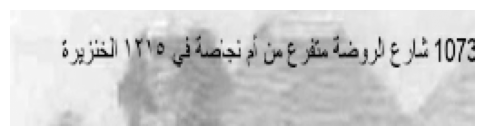

In [57]:
plt.figure(figsize=(6, 3))

image = batch["image"][0]

plt.imshow(tf.transpose(image, [1, 0, 2]), cmap="gray")

plt.axis("off")

plt.show()

In [58]:
label = batch["label"][0]

# Filter out padding tokens (0, which correspond to '[UNK]')
filtered_label = tf.gather(label, tf.where(tf.not_equal(label, 0)))

text = tf.strings.reduce_join(
    num_to_char(filtered_label)
)

print(text.numpy().decode("utf-8"))

1073 شارع الروضة متفرع من أم نجاصة في ١٢١٥ الخنزيرة


## Build CRNN Backbone

In [59]:
from tensorflow.keras.layers import (Input,Conv2D,MaxPooling2D,Bidirectional,LSTM,Dense,BatchNormalization,Reshape)
from tensorflow.keras.models import Model


def build_crnn_model(input_shape, vocab_size):
    inputs = Input(shape=input_shape, name="image_input")

    x = Conv2D(64,(3,3),activation="relu",padding="same")(inputs)
    x = MaxPooling2D((1,2))(x)
    x = BatchNormalization()(x)
    x = Conv2D(128,(3,3),activation="relu",padding="same")(x)
    x = MaxPooling2D((1,2))(x)
    x = BatchNormalization()(x)
    x = Conv2D(256,(3,3),activation="relu",padding="same")(x)
    x = MaxPooling2D((1,2))(x)
    x = BatchNormalization()(x)
    x = Conv2D(512,(3,3),activation="relu",padding="same")(x)
    x = MaxPooling2D((1,2))(x)
    x = BatchNormalization()(x)

    # Convert CNN features to sequence
    shape = x.shape
    x = Reshape((shape[1], shape[2] * shape[3]))(x)
    x = Bidirectional(LSTM(256, return_sequences=True, dropout=0.25))(x)
    x = Bidirectional(LSTM(256, return_sequences=True, dropout=0.25))(x)
    outputs = Dense(vocab_size + 1, activation="softmax", name="char_prediction")(x)

    return Model(inputs, outputs)

## Create Custom CTCLayer (Serializable)

In [65]:
@tf.keras.utils.register_keras_serializable(package="ocr")
class CTCLayer(layers.Layer):
    def __init__(self, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    # Add label_length as an argument to the call method
    def call(self, y_true, y_pred, label_length):
        batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
        input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")

        input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
        # Ensure label_length is (batch_size, 1) and of int64 type
        label_length = tf.cast(label_length, dtype="int64")
        label_length = tf.expand_dims(label_length, axis=-1)

        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)

        return y_pred

    def get_config(self):
        config = super().get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

## Create Training Model

In [66]:
class CTCTrainingModel(Model):
    def __init__(self, cnn_rnn_model, **kwargs):
        super().__init__(**kwargs)
        self.cnn_rnn_model = cnn_rnn_model
        self.loss_layer = CTCLayer(name="ctc_loss")

    def call(self, inputs):
        images = inputs["image"]
        labels = inputs["label"]
        label_lengths = inputs["label_length"] # Extract the true label lengths
        y_pred = self.cnn_rnn_model(images)
        # Pass label_lengths to the CTCLayer
        loss = self.loss_layer(labels, y_pred, label_lengths)
        return loss

## Compile Model

In [67]:
# Build the CRNN model (feature extractor + RNN)
crnn_model = build_crnn_model(
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 1),
    vocab_size=VOCAB_SIZE
)

# Create the training model that wraps the CRNN model and adds the CTC loss
training_model = CTCTrainingModel(cnn_rnn_model=crnn_model)

# Compile the training model with a reduced learning rate
training_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001))

print("Model compiled successfully with reduced learning rate!")

Model compiled successfully with reduced learning rate!


In [68]:
ctc_time_steps = crnn_model.output_shape[1]
min_required_time_steps = 2 * MAX_LABEL_LENGTH - 1  # worst case: every adjacent char pair repeats

print(f"Model output time steps                : {ctc_time_steps}")
print(f"Minimum required for CTC feasibility    : {min_required_time_steps}")
print(f"Longest label length in dataset         : {MAX_LABEL_LENGTH}")

assert ctc_time_steps >= min_required_time_steps, (
    f"CTC time steps ({ctc_time_steps}) are too short for labels up to "
    f"{MAX_LABEL_LENGTH} chars (needs >= {min_required_time_steps} to allow "
    "for repeated adjacent characters). Training will produce inflated loss "
    "and garbage predictions. Reduce pooling on the time (width) axis in "
    "build_crnn_model, or increase IMG_WIDTH, then rebuild the model."
)
print("CTC time-step feasibility check passed \u2705")

Model output time steps                : 256
Minimum required for CTC feasibility    : 153
Longest label length in dataset         : 77
CTC time-step feasibility check passed ✅


In [69]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_callback = ModelCheckpoint(
    filepath='best_model.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    save_freq='epoch',
    verbose=1
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Learning-rate scheduling: halve the LR when val_loss plateaus for 2 epochs,
# down to a floor of 1e-6. This lets training start reasonably fast and still
# fine-tune once progress stalls, instead of being stuck at a single fixed LR
# for all 30 epochs.
reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("ModelCheckpoint, EarlyStopping, and ReduceLROnPlateau callbacks defined.")

ModelCheckpoint, EarlyStopping, and ReduceLROnPlateau callbacks defined.


## Train Model

In [70]:
history = training_model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=[checkpoint_callback, early_stopping_callback, reduce_lr_callback],
    verbose=1
)

Epoch 1/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - loss: 6494.6793
Epoch 1: val_loss improved from None to 3473.08472, saving model to best_model.weights.h5

Epoch 1: finished saving model to best_model.weights.h5
563/563 ━━━━━━━━━━━━━━━━━━━━ 202s 339ms/step - loss: 4652.8188 - val_loss: 3473.0847 - learning_rate: 1.0000e-04
Epoch 2/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - loss: 3317.0681
Epoch 2: val_loss improved from 3473.08472 to 2966.24097, saving model to best_model.weights.h5

Epoch 2: finished saving model to best_model.weights.h5
563/563 ━━━━━━━━━━━━━━━━━━━━ 191s 339ms/step - loss: 3173.6255 - val_loss: 2966.2410 - learning_rate: 1.0000e-04
Epoch 3/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 3321.6179
Epoch 3: val_loss did not improve from 2966.24097
563/563 ━━━━━━━━━━━━━━━━━━━━ 192s 340ms/step - loss: 3497.0322 - val_loss: 3392.5400 - learning_rate: 1.0000e-04
Epoch 4/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 3232.1328
Epoch 4: val_loss impro

### Plotting Training History

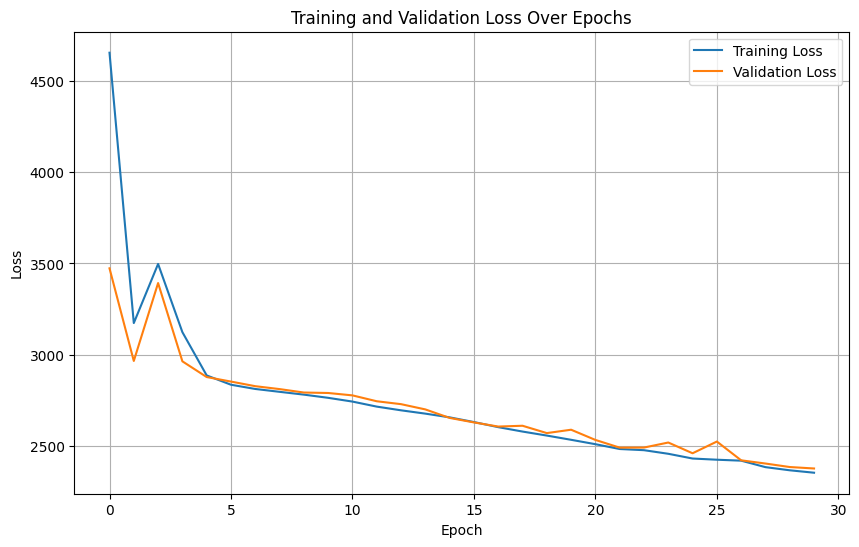

In [71]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Decoding Predictions

In [72]:
def decode_batch_predictions(pred):
    """Fast greedy decoding. Good for quick visual sanity checks during
    training/dev, since it runs in a single pass with no search."""
    input_len = np.ones(pred.shape[0]) * pred.shape[1]

    # Use greedy search. For beam search, use decode_batch_predictions_beam below.
    results = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0]

    # Iterate over the results and get back the text
    output_text = []
    for res in results:
        res = tf.gather(res, tf.where(tf.not_equal(res, -1)))
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        output_text.append(res)
    return output_text


def decode_batch_predictions_beam(pred, beam_width=10):
    """Beam-search decoding. Slower than greedy (explores multiple hypotheses
    per time step) but more accurate, since it doesn't commit to the single
    highest-probability character at each step. Use this for the final CER
    evaluation and for the deployed FastAPI /predict endpoint, where
    per-request latency matters far less than getting the text right."""
    input_len = np.ones(pred.shape[0]) * pred.shape[1]

    results = tf.keras.backend.ctc_decode(
        pred, input_length=input_len, greedy=False, beam_width=beam_width
    )[0][0]

    output_text = []
    for res in results:
        res = tf.gather(res, tf.where(tf.not_equal(res, -1)))
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        output_text.append(res)
    return output_text

print("Greedy and beam-search decoding functions defined.")

Greedy and beam-search decoding functions defined.


### Save the Best Model

In [74]:
import os

# To ensure crnn_model's layers are built, call it with a dummy input first
# This is important before loading weights, especially with save_weights_only=True
for batch in validation_dataset.take(1):
    _ = crnn_model(batch["image"])
    break

# The early stopping callback with `restore_best_weights=True` ensures that the training_model
# (and thus crnn_model) already holds the best weights. So, we just need to save it.
print("Model weights have been restored to the best performing epoch by EarlyStopping.")

DEPLOY_DIR = "./deployment_artifacts"
os.makedirs(DEPLOY_DIR, exist_ok=True)

# 1) Save the inference model (architecture + weights). crnn_model contains
#    no custom layers (CTCLayer only lives in the training wrapper), so this
#    loads in FastAPI with a plain keras.models.load_model(path) call --
#    no custom_objects registration required.
model_export_path = os.path.join(DEPLOY_DIR, "crnn_ocr_model.keras")
crnn_model.save(model_export_path)

# 2) Re-save the vocabulary from the char_to_num lookup actually used by this
#    trained model (not just the copy saved earlier in the notebook), so the
#    vocab shipped to FastAPI is guaranteed to match this exact model, even
#    if cells get re-run out of order later.
vocab_export_path = os.path.join(DEPLOY_DIR, "vocab.json")
with open(vocab_export_path, "w", encoding="utf-8") as f:
    json.dump(char_to_num.get_vocabulary(), f, ensure_ascii=False, indent=4)

# 3) Save the preprocessing/decoding config FastAPI needs to reproduce this
#    exact pipeline: image size, max label length, vocab size, the CTC time
#    dimension, and the blank-token index (ctc_batch_cost assumes blank is
#    the last class, i.e. index == VOCAB_SIZE).
config_export_path = os.path.join(DEPLOY_DIR, "config.json")
config_data = {
    "IMG_WIDTH": IMG_WIDTH,
    "IMG_HEIGHT": IMG_HEIGHT,
    "MAX_LABEL_LENGTH": MAX_LABEL_LENGTH,
    "VOCAB_SIZE": VOCAB_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "CTC_TIME_STEPS": crnn_model.output_shape[1],
    "BLANK_INDEX": VOCAB_SIZE,
}
with open(config_export_path, "w", encoding="utf-8") as f:
    json.dump(config_data, f, ensure_ascii=False, indent=4)

print(f"Deployment artifacts saved to {DEPLOY_DIR}/")
print(" -", model_export_path)
print(" -", vocab_export_path)
print(" -", config_export_path)

Model weights have been restored to the best performing epoch by EarlyStopping.
Deployment artifacts saved to ./deployment_artifacts/
 - ./deployment_artifacts/crnn_ocr_model.keras
 - ./deployment_artifacts/vocab.json
 - ./deployment_artifacts/config.json


In [75]:
# --- Sanity check: reload the saved artifacts exactly the way FastAPI will,
# and confirm predictions match the in-memory model. This is the single most
# important check before deploying -- it catches serialization mismatches
# (e.g. custom layers, dtype drift) before they become a production bug. ---
reloaded_model = keras.models.load_model(model_export_path)  # no custom_objects needed

with open(vocab_export_path, "r", encoding="utf-8") as f:
    reloaded_vocab = json.load(f)

assert reloaded_vocab == char_to_num.get_vocabulary(), (
    "Reloaded vocab.json does not match the training vocabulary -- "
    "decoding in FastAPI would produce wrong characters!"
)

for batch in validation_dataset.take(1):
    sample_images = batch["image"]
    original_preds = crnn_model.predict(sample_images)
    reloaded_preds = reloaded_model.predict(sample_images)
    break

max_diff = float(np.max(np.abs(original_preds - reloaded_preds)))
print(f"Max prediction difference after reload: {max_diff:.8f}")

assert max_diff < 1e-5, (
    "Reloaded model outputs differ from the in-memory model -- "
    "there is a serialization issue, do not deploy this artifact."
)
print("Reload sanity check passed -- deployment_artifacts/ is safe to ship to FastAPI.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step
Max prediction difference after reload: 0.00000000
Reload sanity check passed -- deployment_artifacts/ is safe to ship to FastAPI.


In [77]:
print("config.json is now saved in ./deployment_artifacts/ -- see the export cell above.")

config.json is now saved in ./deployment_artifacts/ -- see the export cell above.


In [78]:
import editdistance

# Function to calculate Character Error Rate (CER)
def calculate_cer(y_true, y_pred):
    '''Calculates the Character Error Rate: total edit distance divided by
    total number of ground-truth characters (the standard CER definition).
    The previous version divided by the number of *samples*, which reported
    "avg chars wrong per sample" and was not a normalized rate.'''
    total_edit_distance = 0
    total_chars = 0
    for true_label, pred_label in zip(y_true, y_pred):
        total_edit_distance += editdistance.eval(true_label, pred_label)
        total_chars += len(true_label)
    return total_edit_distance / total_chars

print("CER calculation function defined.")

CER calculation function defined.


In [79]:
print("Calculating CER on validation dataset (beam search, beam_width=10)...")

validation_true_labels = []
validation_pred_labels = []

for batch in validation_dataset:
    images = batch["image"]
    labels = batch["label"]

    # Get predictions from the CRNN model
    preds = crnn_model.predict(images)
    pred_texts = decode_batch_predictions_beam(preds, beam_width=10)
    validation_pred_labels.extend(pred_texts)

    # Decode true labels
    for i in range(len(labels)):
        original_label = tf.gather(labels[i], tf.where(tf.not_equal(labels[i], 0)))
        original_label = tf.strings.reduce_join(num_to_char(original_label)).numpy().decode("utf-8")
        validation_true_labels.append(original_label)

# Calculate overall CER (total edit distance / total ground-truth characters)
overall_cer = calculate_cer(validation_true_labels, validation_pred_labels)
print(f"Overall Character Error Rate (CER) on validation set: {overall_cer:.4f}")

Calculating CER on validation dataset (beam search, beam_width=10)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms